# ClearPath DQR + Cleaning Pipeline

**Data Source**: Docker MySQL `clearpath` (loaded by `database_build.ipynb`)

**Structure**: Executive Summary → Data Profiling → Quality Dimensions → Anomaly Detection → DQ Score → Cleaning Pipeline → Action Items → Appendix

**Target ML**: Busyness prediction (time series + user reports)

---
## Part 0: Configuration & DB Connection

In [1]:
import sys
import pandas as pd
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Paths (absolute — kernel cwd is project root)
PROJECT_ROOT = Path('/Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project')
TEST_ROOT = PROJECT_ROOT / 'Data+ML' / 'test'
OUTPUT_DIR = TEST_ROOT / '6.8-6.12_DB' / 'tests' / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(TEST_ROOT))

# ── 精简后只有 3 个模块 ──
DQR_TABLES = (
    'venues', 'restroom_profiles', 'healthcare_profiles', 'emergency_assets',
    'pedestrian_ramps', 'venue_source_links', 'busyness_scores',
    'external_context_cache', 'user_reports',
)

# dqr_checks.py: 质量检查 + 画像 + 清洗 + 评分 + 改进建议
from dqr.dqr_checks import (
    DQ_WEIGHTS,
    # 质量检查（4 项）
    check_completeness, check_accuracy, check_database_integrity, check_fk_orphans,
    # 六维度评分
    compute_dq_scores, compute_total_score,
    # 数据画像
    build_all_profiles, build_record_analysis,
    # 异常检测
    detect_coordinate_anomalies, detect_gps_duplicates,
    # 清洗
    clean_venues,
    # 改进建议 + ML 评估
    build_action_items, assess_ml_usability,
)

# dqr_utils.py: 数据库连接 + 地理工具 + 外部 API
from dqr.dqr_utils import (
    MANHATTAN_BOUNDS, get_conn, is_manhattan, validate_coords, gps_to_district,
    fetch_traffic_hourly, clean_traffic, fetch_and_clean_weather,
)

# dqr_io.py: SQL 查询 + CSV 导出
from dqr.dqr_io import query_table, load_dqr_tables, export_dqr_artifacts, build_audit_report

print(f'Project: {PROJECT_ROOT}  |  Output: {OUTPUT_DIR}')
print(f'Started: {datetime.now():%Y-%m-%d %H:%M}')

Project: /Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project  |  Output: /Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/6.8-6.12_DB/tests/output
Started: 2026-06-13 13:51


---
## 1. Executive Summary

In [2]:
# 直接调用底层函数，不需要 pipeline 层
conn = get_conn()
data = load_dqr_tables(conn, DQR_TABLES)
conn.close()

df_venues = data.get('venues', pd.DataFrame())
total_rows = sum(len(df) for df in data.values() if not df.empty)
tables_loaded = sum(1 for df in data.values() if not df.empty)
completeness = round(100 - df_venues.isnull().mean().mean() * 100, 1)
venue_types = df_venues['venue_type'].value_counts().to_dict() if 'venue_type' in df_venues.columns else {}

print(f'={"="*58}')
print('  EXECUTIVE SUMMARY — ClearPath DQR')
print(f'  DB: clearpath (Docker MySQL)')
print(f'  Total lines: {total_rows:,}  |  Tables loaded: {tables_loaded}/{len(DQR_TABLES)}')
print(f'  Venue: {len(df_venues):,}  |  Type: {venue_types}')
print(f'  Completeness: {completeness:.1f}%  |  Date: {datetime.now():%Y-%m-%d}')
print(f'={"="*58}')

venues                         →  4,838 rows, 24 cols
restroom_profiles              →    473 rows, 10 cols
healthcare_profiles            →  1,086 rows,  9 cols
emergency_assets               →  3,279 rows, 10 cols


/Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/dqr/dqr_io.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


pedestrian_ramps               → 23,625 rows, 17 cols
venue_source_links             →  4,838 rows,  9 cols
busyness_scores                →      0 rows, 11 cols
external_context_cache         →      1 rows,  8 cols
user_reports                   →      0 rows, 18 cols
  EXECUTIVE SUMMARY — ClearPath DQR
  DB: clearpath (Docker MySQL)
  Total lines: 38,140  |  Tables loaded: 7/9
  Venue: 4,838  |  Type: {'emergencyasset': 3279, 'healthcare': 1086, 'restroom': 473}
  Completeness: 63.5%  |  Date: 2026-06-13


/Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/dqr/dqr_io.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


---
## 2. Data Profiling

In [3]:
all_profiles = build_all_profiles(data)  # 对所有表的字段进行数据画像分析，返回一个 DataFrame，包含每个字段的统计信息和质量指标。
record_analysis = build_record_analysis(df_venues) #对场馆数据进行记录级别的分析，返回一个 DataFrame，包含每条记录的质量评分和相关指标。

print(f'Column profiling: {len(all_profiles)} fields across {tables_loaded} tables')
if not all_profiles.empty:
    display(all_profiles.head(10))

if not record_analysis.empty:
    quality_values = record_analysis['record_quality_score']
    print(f'Record quality: mean={quality_values.mean():.2f}, min={quality_values.min():.2f}, '
          f'low(<0.5)={(quality_values < 0.5).sum()}')

Column profiling: 87 fields across 7 tables


/Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/dqr/dqr_checks.py:276: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


,table,column,dtype,non_null,total,missing_pct,nunique,mode,min,max,mean,std
0,venues,venue_id,object,4838,4838,0.0,4838,0006c1aef358bc9d07ac1a05258679fbfa71,NaN,NaN,NaN,NaN
1,venues,venue_type,object,4838,4838,0.0,3,emergencyasset,NaN,NaN,NaN,NaN
2,venues,name,object,4838,4838,0.0,2782,"Walt Disney/ABC, Inc. AED",NaN,NaN,NaN,NaN
3,venues,latitude,float64,4838,4838,0.0,2621,0.0,0.000000,40.883045,39.72,6.44
4,venues,longitude,float64,4838,4838,0.0,2590,0.0,-74.022864,0.000000,-72.08,11.69
5,venues,borough,object,4500,4838,7.0,11,Manhattan,NaN,NaN,NaN,NaN
6,venues,address,object,4731,4838,2.2,2659,750 SEVENTH AVENUE,NaN,NaN,NaN,NaN
7,venues,phone,object,800,4838,83.5,729,2122417005,NaN,NaN,NaN,NaN
8,venues,website,object,505,4838,89.6,478,www.premierhomehealthcare.com,NaN,NaN,NaN,NaN
9,venues,opening_hours,object,370,4838,92.4,260,24/7,NaN,NaN,NaN,NaN


Record quality: mean=1.00, min=0.83, low(<0.5)=0


---
## 3. Data Quality Dimensions

In [4]:
# ── 直接调用各检查函数 ──
completeness_result = check_completeness(data)
accuracy_result = check_accuracy(df_venues)
integrity_result = check_database_integrity(df_venues)

for name, result in [('completeness', completeness_result),
                     ('accuracy', accuracy_result),
                     ('integrity', integrity_result)]:
    status = 'PASS' if result['passed'] else 'FAIL'
    issues = f'  issues={result["issues"]}' if result['issues'] else ''
    print(f'  {name:<15} score={result["score"]:>6.1f}  {status}{issues}')

# 坐标校验掩码供后续使用
coord_valid_mask = accuracy_result.get('_coord_valid_mask')

print('\nCompleteness detail:')
print(completeness_result['_dataframe'].to_string(index=False))

  completeness    score=  97.0  PASS
  accuracy        score= 100.0  PASS
  integrity       score=  97.4  FAIL  issues=['124 venues with null district', '124/124 have GPS (0,0)']

Completeness detail:
              table               field  filled  total  completeness_pct
             venues            venue_id    4838   4838             100.0
             venues          venue_type    4838   4838             100.0
             venues                name    4838   4838             100.0
             venues            latitude    4838   4838             100.0
             venues           longitude    4838   4838             100.0
             venues            district    4714   4838              97.4
  restroom_profiles            venue_id     473    473             100.0
  restroom_profiles              status     349    473              73.8
  restroom_profiles       restroom_type     392    473              82.9
healthcare_profiles            venue_id    1086   1086             10

---
## 4. Anomaly Detection

In [5]:
anomaly_df = detect_coordinate_anomalies(data) # 检测坐标越界
gps_duplicates_df = detect_gps_duplicates(data, threshold_m=10) # 检测 GPS 重复（10m 阈值）

print(f'Anomalies: {len(anomaly_df)}')
if not anomaly_df.empty:
    print(anomaly_df['type'].value_counts().to_string())

print(f'GPS duplicates (<10m): {len(gps_duplicates_df)} pairs')
if not gps_duplicates_df.empty:
    display(gps_duplicates_df.head(5))

GPS duplicates: 701 pairs found in 0.08s
Anomalies: 315
type
outside_manhattan    191
zero_coordinates     124
GPS duplicates (<10m): 701 pairs


,table_a,id_a,name_a,table_b,id_b,name_b,distance_m
0,venues,0006c1aef358bc9d07ac1a05258679fbfa71,Columbia University Health Care Mobile Van,pedestrian_ramps,310448,310448,9.0
1,venues,0006c1aef358bc9d07ac1a05258679fbfa71,Columbia University Health Care Mobile Van,pedestrian_ramps,310432,310432,6.6
2,venues,5d2300a051ae684e887fa829fb88aa046d3e,Columbia University Health Care Mobile Van,pedestrian_ramps,310448,310448,9.0
3,venues,5d2300a051ae684e887fa829fb88aa046d3e,Columbia University Health Care Mobile Van,pedestrian_ramps,310432,310432,6.6
4,venues,0184f293c4edefc10c8c9566bf920a91e643,CHN - Community League Center,pedestrian_ramps,200556,200556,5.5


---
## 5. DQ Score & Rating


In [6]:
# 修复 borough（坐标在曼哈顿但 borough 不是 Manhattan 的，统一修正）
if 'borough' in df_venues.columns and 'latitude' in df_venues.columns:
    fixed = 0
    for idx, row in df_venues.iterrows():
        if pd.notna(row.get('latitude')) and pd.notna(row.get('longitude')):
            if is_manhattan(float(row['latitude']), float(row['longitude'])):
                if row.get('borough') != 'Manhattan':
                    df_venues.at[idx, 'borough'] = 'Manhattan'
                    fixed += 1
    if fixed > 0:
        print(f'Borough: fixed {fixed} records → Manhattan')

# 计算6维度评分
scores = compute_dq_scores(df_venues, data, anomaly_df, gps_duplicates_df, coord_valid_mask)
total_score, grade = compute_total_score(scores)

print('DQ SCORE & RATING')
print(f'{"Dimension":<18} {"Weight":>7} {"Score":>7} {"Weighted":>8}')
print('-' * 42)
for dimension in DQ_WEIGHTS:
    s = scores[dimension]
    print(f'{dimension:<18} {DQ_WEIGHTS[dimension]:>6.0%} {s:>7.1f} '
          f'{s * DQ_WEIGHTS[dimension]:>8.1f}')
print('-' * 42)
print(f'{"TOTAL":<18} {"100%":>7} {total_score:>7.1f}')
print(f'Rating: {grade} ({total_score:.1f}/100)')

Borough: fixed 983 records → Manhattan
DQ SCORE & RATING
Dimension           Weight   Score Weighted
------------------------------------------
Completeness          25%    99.6     24.9
Accuracy              25%    93.5     23.4
Consistency           15%    99.6     14.9
Uniqueness            15%    85.5     12.8
Timeliness            10%    95.0      9.5
Validity              10%   100.0     10.0
------------------------------------------
TOTAL                 100%    95.5
Rating: Excellent (95.5/100)


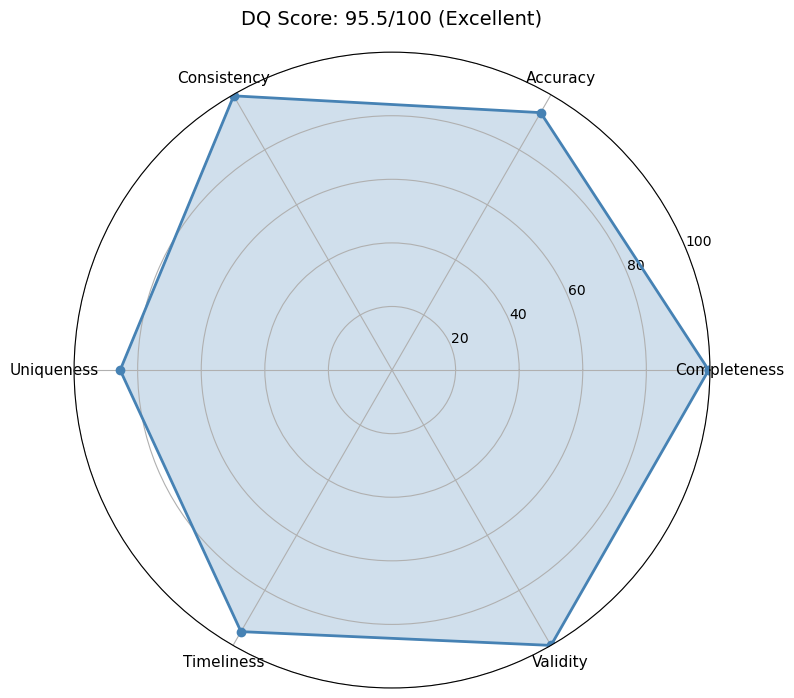

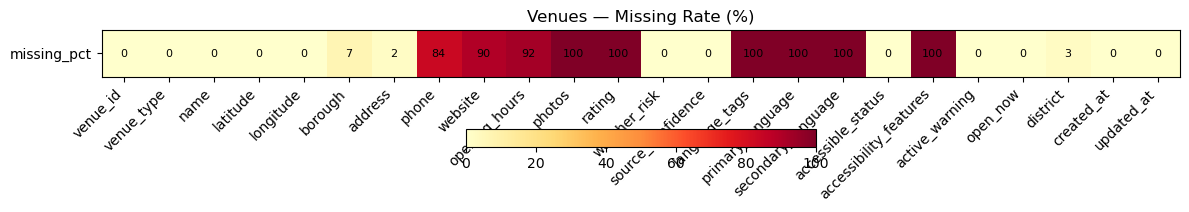

In [7]:
# Radar chart
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
dimensions = list(scores)
values = [scores[name] for name in dimensions]
angles = np.linspace(0, 2 * np.pi, len(dimensions), endpoint=False).tolist()
values_plot = values + [values[0]]
angles += angles[:1]
ax.fill(angles, values_plot, alpha=0.25, color='steelblue')
ax.plot(angles, values_plot, 'o-', color='steelblue', linewidth=2)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(dimensions, size=11)
ax.set_ylim(0, 100)
ax.set_title(f'DQ Score: {total_score:.1f}/100 ({grade})', size=14, pad=20)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'dqr_dimension_scores.png', dpi=150); plt.show()

# Missing rate heatmap
venue_profile = all_profiles[all_profiles['table'] == 'venues'].copy()
if not venue_profile.empty:
    fig, ax = plt.subplots(figsize=(12, 2))
    missing_values = venue_profile['missing_pct'].to_numpy()[None, :]
    image = ax.imshow(missing_values, cmap='YlOrRd', vmin=0, vmax=100, aspect='auto')
    ax.set_xticks(range(len(venue_profile)), labels=venue_profile['column'], rotation=45, ha='right')
    ax.set_yticks([0], labels=['missing_pct'])
    for column_index, value in enumerate(missing_values[0]):
        ax.text(column_index, 0, f'{value:.0f}', ha='center', va='center', fontsize=8)
    fig.colorbar(image, ax=ax, orientation='horizontal', pad=0.45)
    ax.set_title('Venues — Missing Rate (%)')
    plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'dqr_missing_heatmap.png', dpi=150); plt.show()

---
## 6. Cleaning Pipeline & External Data

  Coords: removed 0 invalid records (cached mask)
  Kept: 4838 records (quality_score mean=1.00)
venues_clean: 4838 records


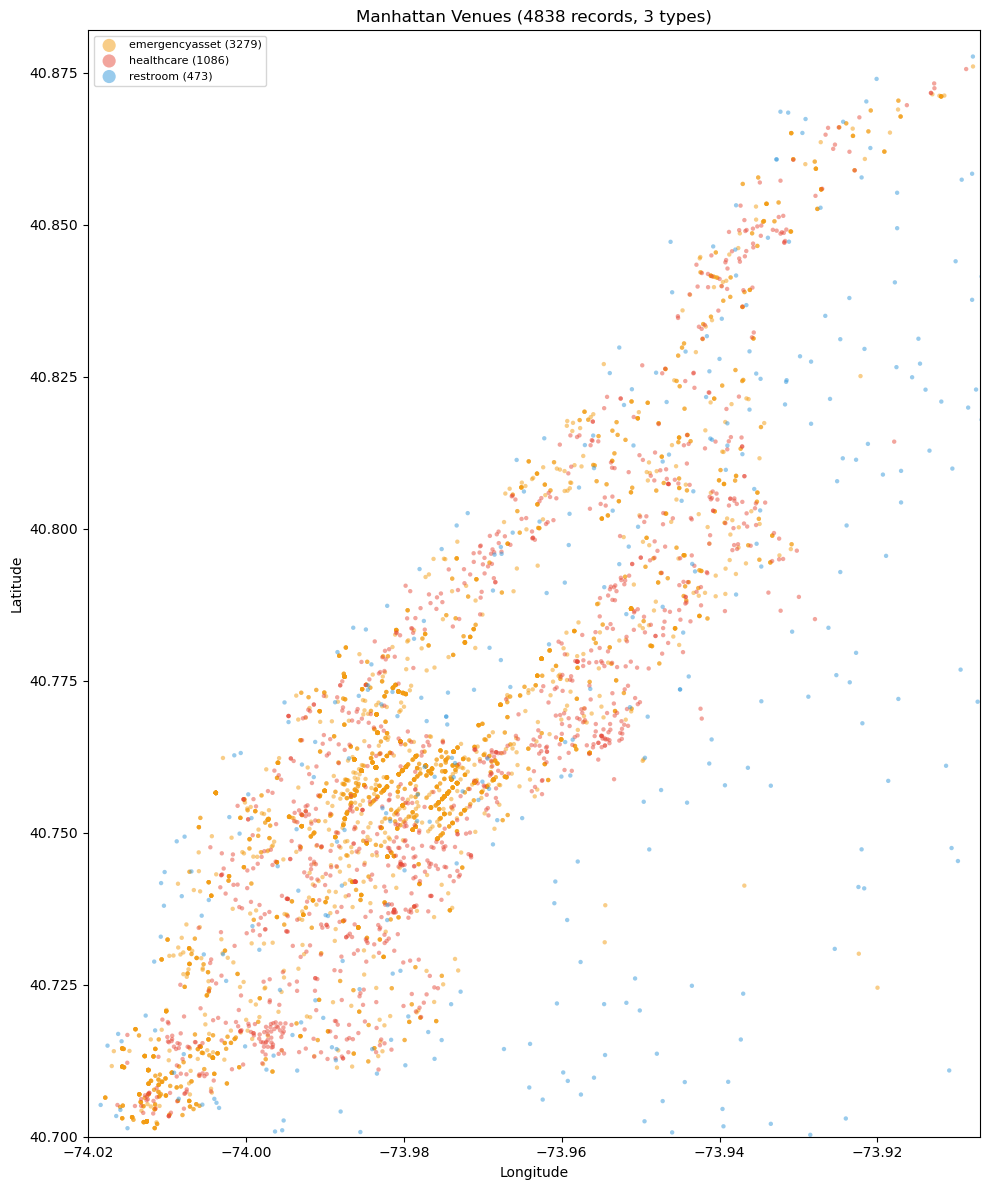

In [8]:
quality_scores = record_analysis['record_quality_score'] if not record_analysis.empty else None
venues_clean = clean_venues(df_venues, coord_valid_mask=coord_valid_mask, quality_scores=quality_scores)
print(f'venues_clean: {len(venues_clean)} records')

if not venues_clean.empty and 'latitude' in venues_clean.columns:
    fig, ax = plt.subplots(figsize=(10, 12))
    colors = {'emergencyasset': '#f39c12', 'healthcare': '#e74c3c', 'restroom': '#3498db'}
    for venue_type in sorted(venues_clean['venue_type'].unique()):
        subset = venues_clean[venues_clean['venue_type'] == venue_type]
        ax.scatter(subset['longitude'], subset['latitude'], c=colors.get(venue_type, '#95a5a6'),
                   label=f'{venue_type} ({len(subset)})', alpha=0.5, s=10, edgecolors='none')
    ax.set(xlabel='Longitude', ylabel='Latitude',
           title=f'Manhattan Venues ({len(venues_clean)} records, '
                 f'{venues_clean["venue_type"].nunique()} types)',
           xlim=(MANHATTAN_BOUNDS['lng_min'], MANHATTAN_BOUNDS['lng_max']),
           ylim=(MANHATTAN_BOUNDS['lat_min'], MANHATTAN_BOUNDS['lat_max']))
    ax.legend(fontsize=8, markerscale=3)
    plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'dqr_venue_scatter.png', dpi=150); plt.show()

In [9]:
# 外部数据：交通 + 天气（失败不中断）
try:
    traffic_clean = clean_traffic(fetch_traffic_hourly(year=2025))
except Exception as e:
    traffic_clean = pd.DataFrame()
    print(f'Traffic error: {e}')

try:
    weather_clean = fetch_and_clean_weather(raise_errors=True)
except Exception as e:
    weather_clean = pd.DataFrame()
    print(f'Weather error: {e}')

print(f'Traffic rows: {len(traffic_clean)} | Weather rows: {len(weather_clean)}')

Querying SODA API: boro=Manhattan, yr=2025...
  → 792 rows returned
Traffic cleaned: 792 rows, 28 segments
Weather: Sunny, 29.4C, risk=low
Traffic rows: 792 | Weather rows: 1


---
## 7. Action Items & Appendix

In [10]:
# ── Action Items ──
actions_df = build_action_items(df_venues, data, scores)
print('=== Action Items ===')
display(actions_df)

# ── Export CSVs ──
export_dqr_artifacts(
    OUTPUT_DIR, venues_clean=venues_clean, traffic_clean=traffic_clean,
    weather_clean=weather_clean, field_summary=all_profiles,
    record_analysis=record_analysis, anomalies=anomaly_df, gps_duplicates=gps_duplicates_df,
)

# ── ML Usability ──
ml = assess_ml_usability(venues_clean, traffic_clean, weather_clean, scores, grade)
print(f'\n{"="*50}')
print(f'  ML USABILITY: {ml["venues_count"]} venues, {ml["coord_complete_pct"]:.0f}% coords, '
      f'{ml["district_count"]}/4 districts, DQ={total_score:.1f}/100')
print(f'{"="*50}')

=== Action Items ===


,priority,issue,recommendation,owner
0,P1,124 venues with null district,Apply gps_to_district() to fill missing districts,Data+ML
1,P1,1 expired cache entries,Refresh external_context_cache entries,Backend


venues_clean.csv               →  4,838 rows
traffic_hourly.csv             →    792 rows
weather_current.csv            →      1 rows
dqr_field_summary.csv          →     87 rows
dqr_record_analysis.csv        →  4,838 rows
dqr_outliers.csv               →    315 rows
dqr_gps_duplicates.csv         →    701 rows

  ML USABILITY: 4838 venues, 100% coords, 4/4 districts, DQ=95.5/100
